In [108]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import pandas as pd

# T-test

Here I perform a two and one sided t test on given data.

The test statistics:
$$
T_0 = \frac{\bar{x} - \mu_0}{\frac{s}{\sqrt{n}}}
\quad \text{where} \quad
\begin{aligned}
\bar{x} & = \text{sample mean} \\
\mu_0 & = \text{hypothesized population mean} \\
s & = \text{sample standard deviation} \\
n & = \text{sample size}
\end{aligned}
$$

In [67]:
# Sample data
data = np.array([10, 6, 8, 8, 6, 10, 7, 6, 8])
sample_mean = np.mean(data)
sample_std = np.std(data, ddof=1)
n = len(data)

print(f"Sample mean: {sample_mean:.2f}")
print(f"Sample std: {sample_std:.2f}")
print(f"Sample size: {n}")

Sample mean: 7.67
Sample std: 1.58
Sample size: 9


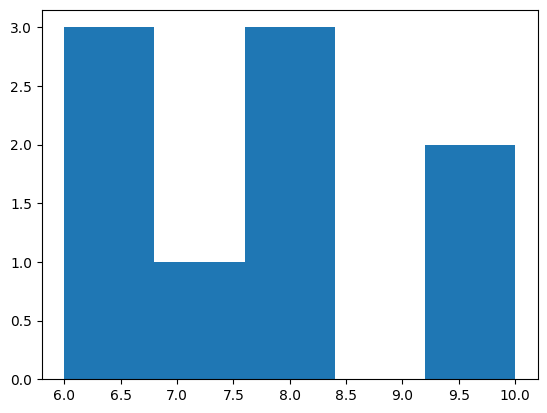

In [55]:
plt.hist(data, bins='auto')
plt.show()

In [56]:
# Step 1: Define the null hypothesis mean (μ₀ = ...)
mu_0 = 8.8

# Step 2: Calculate the value of test statistics T and the p value
t_stat, p_value = stats.ttest_1samp(data, mu_0)

print(f"\nT-statistic: {t_stat:.3f}")
print(f"P-value (two-tailed): {p_value:.4f}")

# Step 3: Compare the p value with alpha
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: the mean is significantly different from μ₀.")
else:
    print("Fail to reject the null hypothesis: no significant difference from μ₀.")



T-statistic: -2.150
P-value (two-tailed): 0.0637
Fail to reject the null hypothesis: no significant difference from μ₀.


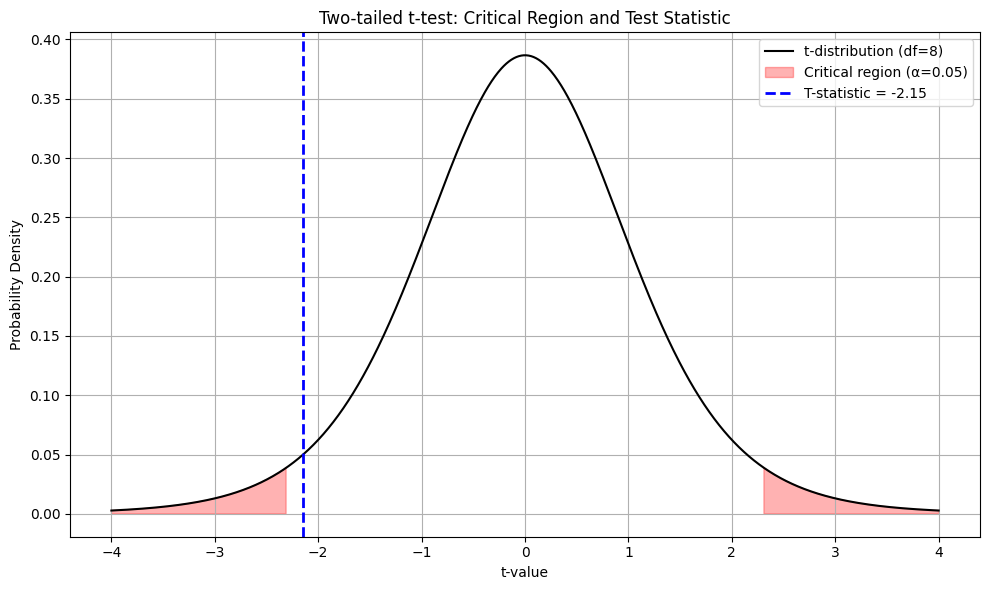

In [58]:
# Critical t-value for two-tailed test
t_crit = stats.t.ppf(1 - alpha / 2, n - 1)

# Create values for the t-distribution curve
x = np.linspace(-4, 4, 1000)
y = stats.t.pdf(x, n - 1)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x, y, label=f't-distribution (df={n - 1})', color='black')

# Shade the critical regions
plt.fill_between(x, y, where=(x <= -t_crit) | (x >= t_crit),
                 color='red', alpha=0.3, label='Critical region (α=0.05)')

# Draw the test statistic
plt.axvline(t_stat, color='blue', linestyle='--', linewidth=2, label=f'T-statistic = {t_stat:.2f}')

# Labels and legend
plt.title("Two-tailed t-test: Critical Region and Test Statistic")
plt.xlabel("t-value")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [57]:
# Step 1: Define the null hypothesis mean (μ₀ = ...)
# mu_0 = ... We use the value defined earlier

# Step 2: Calculate the value of test statistics T and the p value
t_stat, p_value = stats.ttest_1samp(data, mu_0, alternative='less')

print(f"\nT-statistic: {t_stat:.3f}    <- same as before")
print(f"P-value (one-sided): {p_value:.4f}")

# Step 3: Compare the p value with alpha
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: the mean is significantly different from μ₀.")
else:
    print("Fail to reject the null hypothesis: no significant difference from μ₀.")


T-statistic: -2.150    <- same as before
P-value (one-sided): 0.0319
Reject the null hypothesis: the mean is significantly different from μ₀.


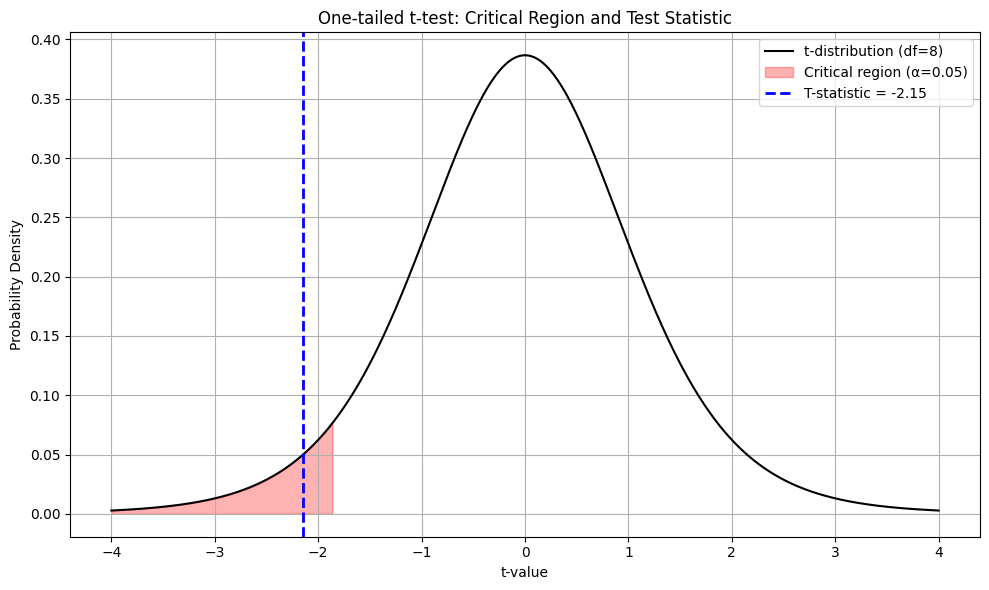

In [66]:
# Critical t-value for two-tailed test
t_crit = stats.t.ppf(alpha, n - 1)

# Create values for the t-distribution curve
x = np.linspace(-4, 4, 1000)
y = stats.t.pdf(x, n - 1)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x, y, label=f't-distribution (df={n - 1})', color='black')

# Shade the critical regions
plt.fill_between(x, y, where=(x <= t_crit),
                 color='red', alpha=0.3, label='Critical region (α=0.05)')

# Draw the test statistic
plt.axvline(t_stat, color='blue', linestyle='--', linewidth=2, label=f'T-statistic = {t_stat:.2f}')

# Labels and legend
plt.title("One-tailed t-test: Critical Region and Test Statistic")
plt.xlabel("t-value")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Chi-squared test

Here I will perform a goodness-of-fit and independence test.

In [100]:
# Example data
observed = np.array([40, 25, 35])
expected = np.array([100/3, 100/3, 100/3])
n = len(observed)

In [105]:
# Chi-squared test
chi2_stat, p_value = stats.chisquare(f_obs=observed, f_exp=expected)

print(f"Chi-squared statistic: {chi2_stat:.3f}")
print(f"P-value: {p_value:.4f}")

# Interpretation
alpha = 0.10
if p_value < alpha:
    print("Reject H0: Observed frequencies significantly differ from expected.")
else:
    print("Fail to reject H0: No significant difference.")


Chi-squared statistic: 3.500
P-value: 0.1738
Fail to reject H0: No significant difference.


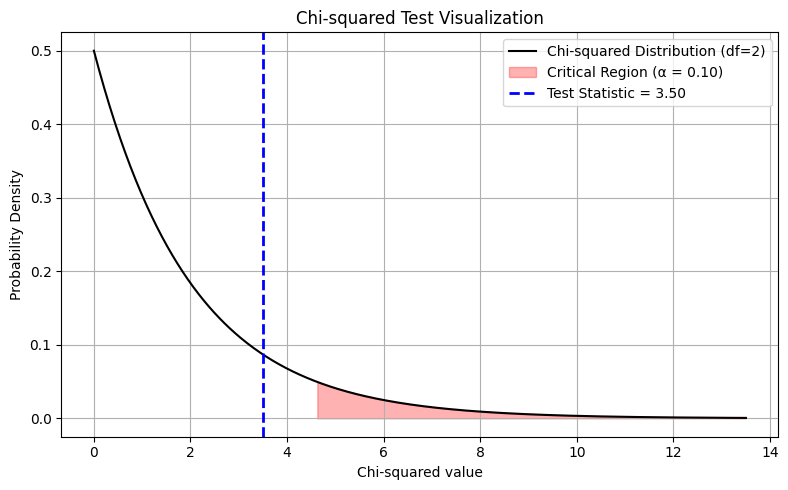

In [107]:
critical_value = stats.chi2.ppf(1 - alpha, n - 1)

# x range for plotting
x = np.linspace(0, chi2_stat + 10, 500)
y = stats.chi2.pdf(x, n - 1)

# Plot the distribution
plt.figure(figsize=(8, 5))
plt.plot(x, y, label=f'Chi-squared Distribution (df={n - 1})', color='black')

# Critical region
plt.fill_between(x, y, where=(x >= critical_value), color='red', alpha=0.3, label=f'Critical Region (α = {alpha:.2f})')

# Plot the test statistic
plt.axvline(chi2_stat, color='blue', linestyle='--', linewidth=2, label=f'Test Statistic = {chi2_stat:.2f}')

# Labels and legend
plt.title('Chi-squared Test Visualization')
plt.xlabel('Chi-squared value')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Chi-squared independence test in contingency table

$$
\chi^2 = \sum_{i=1}^r \sum_{j=1}^c \frac{(O_{ij} - E_{ij})^2}{E_{ij}}
$$

$$
E_{ij} = \frac{(\text{row total}_i) \cdot (\text{column total}_j)}{\text{grand total}}
$$


In [128]:
# Example contingency table
data = np.array([
    [5, 35],
    [10, 25]
])

# Or as a DataFrame for clarity
df = pd.DataFrame(data, index=["Group A", "Group B"], columns=["Success", "Failure"])

In [129]:
# Chi-squared test of independence
chi2, p, dof, expected = stats.chi2_contingency(df)

print(f"Chi-squared statistic: {chi2:.3f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p:.4f}")

# Optional: show expected counts
print("\nExpected frequencies under independence:")
print(pd.DataFrame(expected, index=df.index, columns=df.columns))

# Interpretation
alpha = 0.10
if p < alpha:
    print("Reject H0: The variables are dependent.")
else:
    print("Fail to reject H0: No evidence of dependence.")

Chi-squared statistic: 2.093
Degrees of freedom: 1
P-value: 0.1480

Expected frequencies under independence:
         Success  Failure
Group A      8.0     32.0
Group B      7.0     28.0
Fail to reject H0: No evidence of dependence.


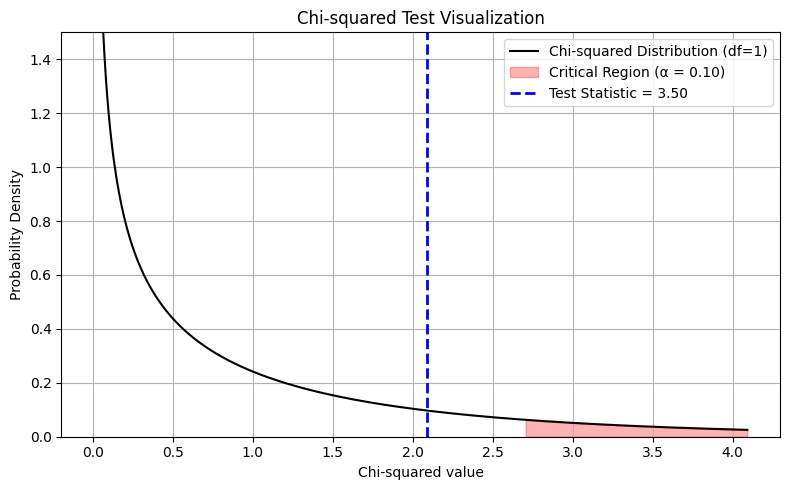

In [133]:
df  = (data.shape[0] - 1) * (data.shape[1] - 1)
critical_value = stats.chi2.ppf(1 - alpha, df)

# x range for plotting
x = np.linspace(0, chi2 + 2, 500)
y = stats.chi2.pdf(x, df)

# Plot the distribution
plt.figure(figsize=(8, 5))
plt.plot(x, y, label=f'Chi-squared Distribution (df={df})', color='black')

# Critical region
plt.fill_between(x, y, where=(x >= critical_value), color='red', alpha=0.3, label=f'Critical Region (α = {alpha:.2f})')

# Plot the test statistic
plt.axvline(chi2, color='blue', linestyle='--', linewidth=2, label=f'Test Statistic = {chi2_stat:.2f}')

# Labels and legend
plt.title('Chi-squared Test Visualization')
plt.xlabel('Chi-squared value')
plt.ylabel('Probability Density')
plt.ylim([0, 1.5])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()